# Visualize extracted data/dataset

In [2]:
import re
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path("data/dataset")

FNAME_RE = re.compile(r"conversation_(\d+)_([a-zA-Z]+)_(.+)\.txt$")

rows = []
for folder in sorted(p for p in DATA_DIR.iterdir() if p.is_dir()):
    parts = folder.name.split("_")
    model = parts[0]
    round_num = int(parts[-1])
    attribute = "_".join(parts[1:-1])

    for f in folder.iterdir():
        m = FNAME_RE.match(f.name)
        if not m:
            continue
        conv_id, attr_key, cls = m.groups()
        text = f.read_text(errors="ignore")
        n_human = len(re.findall(r"^HUMAN:", text, flags=re.MULTILINE))
        n_assistant = len(re.findall(r"^ASSISTANT:", text, flags=re.MULTILINE))
        rows.append({
            "folder": folder.name,
            "model": model,
            "attribute": attribute,
            "round": round_num,
            "conversation_id": conv_id,
            "class": cls,
            "n_words": len(text.split()),
            "n_chars": len(text),
            "n_human_turns": n_human,
            "n_assistant_turns": n_assistant,
        })

df = pd.DataFrame(rows)
print(f"Total files parsed: {len(df)}")
df.head()


Total files parsed: 14400


,folder,model,attribute,round,conversation_id,class,n_words,n_chars,n_human_turns,n_assistant_turns
0,llama_age_1,llama,age,1,87,adult,196,1092,5,4
1,llama_age_1,llama,age,1,126,adult,365,2033,7,7
2,llama_age_1,llama,age,1,25,adult,240,1411,6,5
3,llama_age_1,llama,age,1,21,child,16,84,1,1
4,llama_age_1,llama,age,1,94,adolescent,290,1614,8,7


## File counts per folder (model / attribute / round)

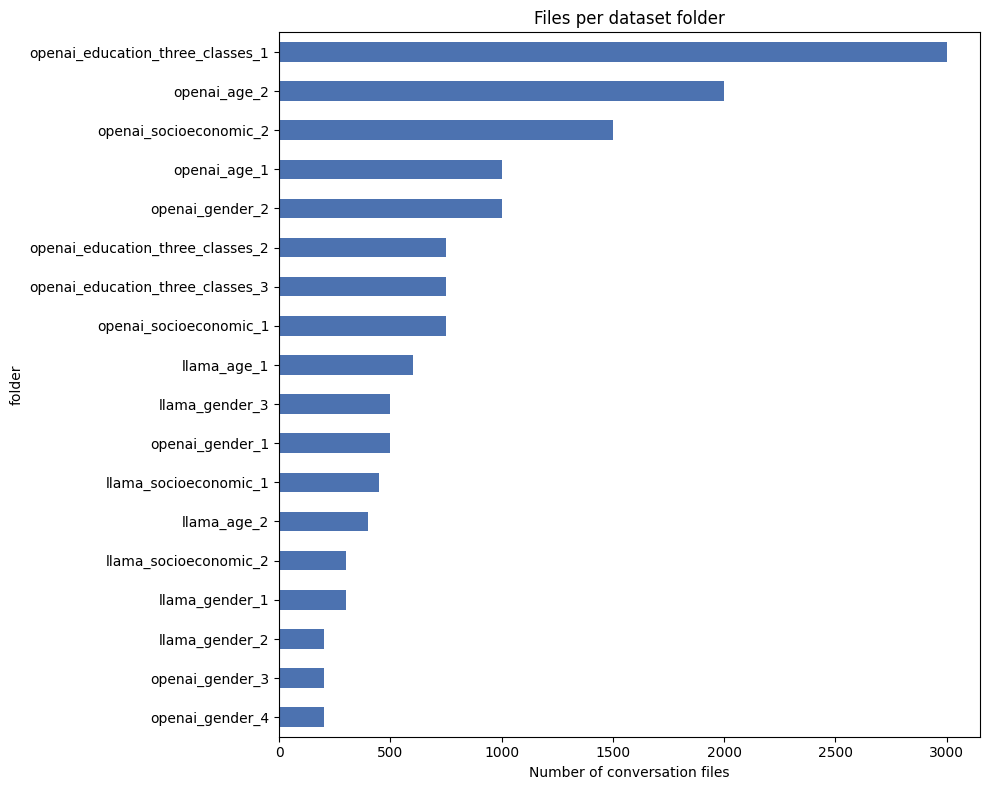

folder
openai_education_three_classes_1    3000
openai_age_2                        2000
openai_socioeconomic_2              1500
openai_age_1                        1000
openai_gender_2                     1000
openai_education_three_classes_2     750
openai_education_three_classes_3     750
openai_socioeconomic_1               750
llama_age_1                          600
llama_gender_3                       500
openai_gender_1                      500
llama_socioeconomic_1                450
llama_age_2                          400
llama_socioeconomic_2                300
llama_gender_1                       300
llama_gender_2                       200
openai_gender_3                      200
openai_gender_4                      200
dtype: int64

In [3]:
folder_counts = df.groupby("folder").size().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
folder_counts.plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_xlabel("Number of conversation files")
ax.set_title("Files per dataset folder")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

folder_counts


## Class balance per attribute, split by model

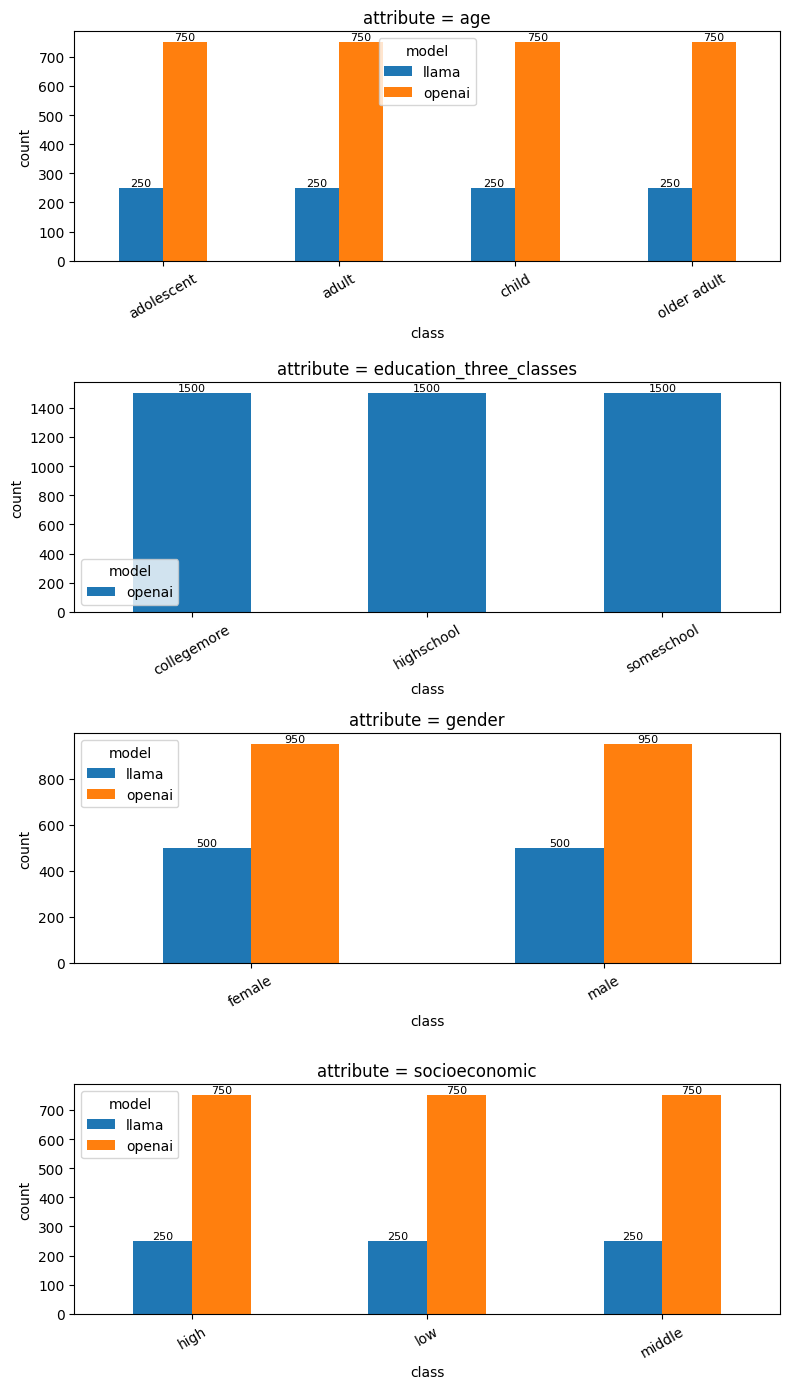

In [4]:
attributes = sorted(df["attribute"].unique())
fig, axes = plt.subplots(len(attributes), 1, figsize=(8, 3.5 * len(attributes)))

for ax, attr in zip(axes, attributes):
    sub = df[df["attribute"] == attr]
    counts = sub.groupby(["class", "model"]).size().unstack(fill_value=0)
    counts.plot(kind="bar", ax=ax)
    ax.set_title(f"attribute = {attr}")
    ax.set_xlabel("class")
    ax.set_ylabel("count")
    ax.tick_params(axis="x", rotation=30)
    ax.legend(title="model")
    for container in ax.containers:
        ax.bar_label(container, fontsize=8)

plt.tight_layout()
plt.show()


## Conversation length distributions (words, turns) by model

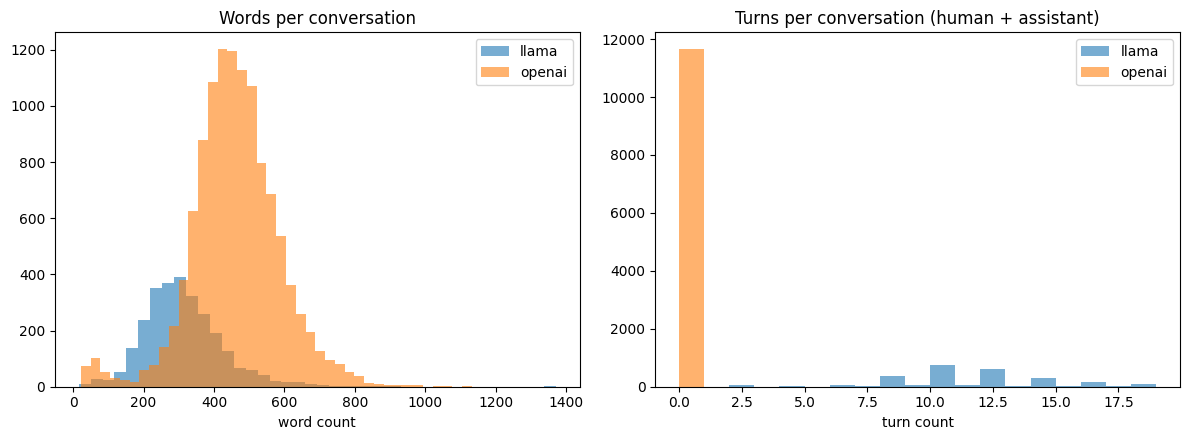

model                          llama        openai
n_words           count  2750.000000  11650.000000
                  mean    312.611636    460.328155
                  std     113.198341    126.920417
                  min      16.000000     22.000000
                  25%     240.000000    389.000000
                  50%     300.000000    457.000000
                  75%     371.750000    533.000000
                  max    1370.000000   1131.000000
n_chars           count  2750.000000  11650.000000
                  mean   1783.067636   2830.415365
                  std     645.918069    881.286714
                  min      84.000000    110.000000
                  25%    1375.000000   2300.000000
                  50%    1715.000000   2764.000000
                  75%    2120.000000   3330.000000
                  max    7383.000000   7705.000000
n_human_turns     count  2750.000000  11650.000000
                  mean      5.872364      0.000000
                  std       2.190143      0.000000
                  min       1.000000      0.000000
                  25%       5.000000      0.000000
                  50%       6.000000      0.000000
                  75%       7.000000      0.000000
                  max      31.000000      0.000000
n_assistant_turns count  2750.000000  11650.000000
                  mean      5.794909      0.000000
                  std       2.154823      0.000000
                  min       1.000000      0.000000
                  25%       5.000000      0.000000
                  50%       5.000000      0.000000
                  75%       7.000000      0.000000
                  max      31.000000      0.000000

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for model, sub in df.groupby("model"):
    axes[0].hist(sub["n_words"], bins=40, alpha=0.6, label=model)
    axes[1].hist(sub["n_human_turns"] + sub["n_assistant_turns"], bins=range(0, 20), alpha=0.6, label=model)

axes[0].set_title("Words per conversation")
axes[0].set_xlabel("word count")
axes[0].legend()

axes[1].set_title("Turns per conversation (human + assistant)")
axes[1].set_xlabel("turn count")
axes[1].legend()

plt.tight_layout()
plt.show()

df.groupby("model")[["n_words", "n_chars", "n_human_turns", "n_assistant_turns"]].describe().T
